# CS412: Machine Learning - Homework 1
## k-Nearest Neighbors on Fashion-MNIST

**Student Name:** Ömer Öztop

**Date:** October 18, 2025

**Notebook Link:** https://github.com/ooztop/CS412_HW1/blob/main/CS412-HW1-YourName.ipynb

---

## Table of Contents
1. [Import Libraries](#1)
2. [Data Loading and Splitting](#2)
3. [Data Analysis](#3)
4. [Preprocessing](#4)
5. [k-NN Hyperparameter Tuning](#5)
6. [Final Model Evaluation](#6)
7. [Error Analysis](#7)
8. [Conclusions](#8)


<a id='1'></a>
## 1. Import Libraries


In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

# Import Fashion-MNIST from Keras
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


<a id='2'></a>
## 2. Data Loading and Splitting

### 2.1 Load Fashion-MNIST Dataset


In [3]:
# Load Fashion-MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Original training set shape: {X_train_full.shape}")
print(f"Original training labels shape: {y_train_full.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")


Original training set shape: (60000, 28, 28)
Original training labels shape: (60000,)
Test set shape: (10000, 28, 28)
Test labels shape: (10000,)


### 2.2 Train-Validation Split

We split the training data into 80% training and 20% validation using stratified sampling to maintain class balance.


In [4]:
# Split training data into train and validation sets (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_full,
    shuffle=True
)

# Print shapes to verify the split
print("\n=== Dataset Shapes ===")
print(f"Training set: {X_train.shape} - {y_train.shape}")
print(f"Validation set: {X_val.shape} - {y_val.shape}")
print(f"Test set: {X_test.shape} - {y_test.shape}")

# Verify stratification
print("\n=== Class Distribution Verification ===")
print(f"Training set class distribution:\n{np.bincount(y_train)}")
print(f"Validation set class distribution:\n{np.bincount(y_val)}")
print(f"Test set class distribution:\n{np.bincount(y_test)}")



=== Dataset Shapes ===
Training set: (48000, 28, 28) - (48000,)
Validation set: (12000, 28, 28) - (12000,)
Test set: (10000, 28, 28) - (10000,)

=== Class Distribution Verification ===
Training set class distribution:
[4800 4800 4800 4800 4800 4800 4800 4800 4800 4800]
Validation set class distribution:
[1200 1200 1200 1200 1200 1200 1200 1200 1200 1200]
Test set class distribution:
[1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


<a id='3'></a>
## 3. Data Analysis

Before preprocessing, we perform exploratory data analysis to understand the dataset better.

### 3.1 Class Distribution


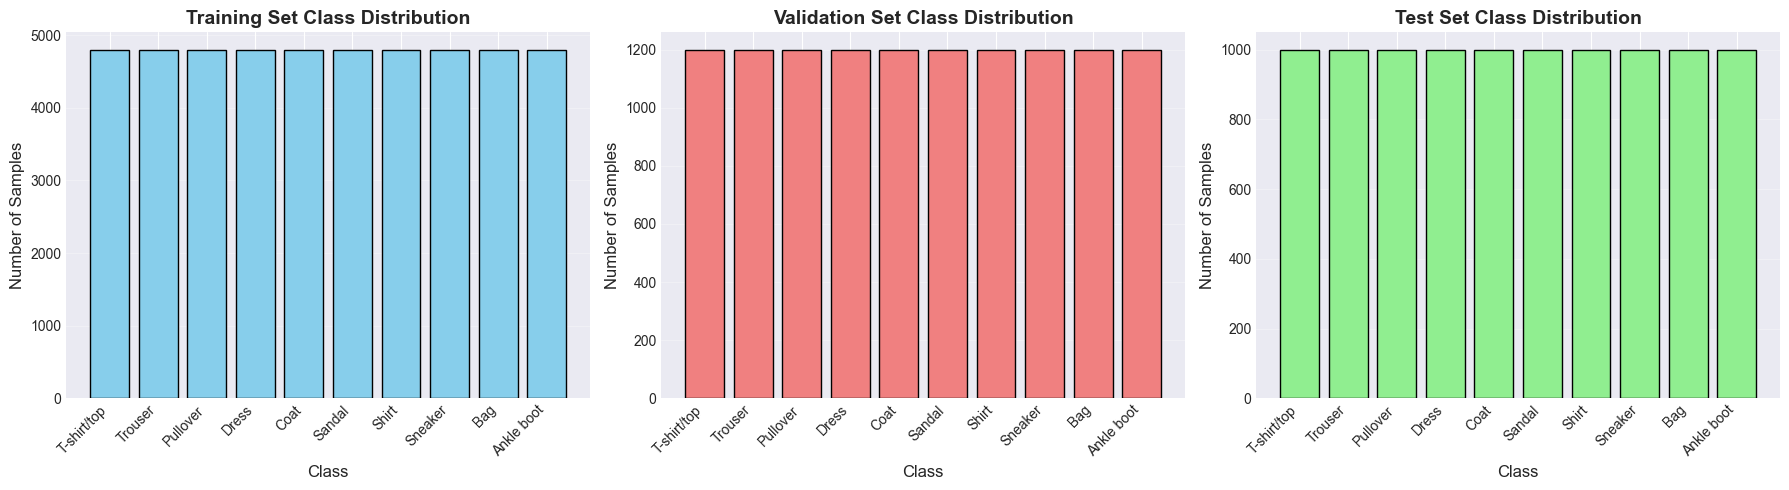

All datasets are balanced with equal representation across classes.


In [ ]:
# Plot class distribution for all datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training set
train_counts = np.bincount(y_train)
axes[0].bar(range(10), train_counts, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Validation set
val_counts = np.bincount(y_val)
axes[1].bar(range(10), val_counts, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Validation Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Test set
test_counts = np.bincount(y_test)
axes[2].bar(range(10), test_counts, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Class', fontsize=12)
axes[2].set_ylabel('Number of Samples', fontsize=12)
axes[2].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(10))
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("All datasets are balanced with equal representation across classes.")


### 3.2 Pixel Statistics


=== Global Pixel Statistics (Training Set) ===
Mean: 72.99
Standard Deviation: 90.06
Min: 0
Max: 255
Pixel value range: [0, 255]

=== Per-Class Mean Pixel Intensity ===
T-shirt/top    : 82.85
Trouser        : 56.99
Pullover       : 96.49
Dress          : 66.12
Coat           : 98.10
Sandal         : 34.80
Shirt          : 84.83
Sneaker        : 42.84
Bag            : 90.17
Ankle boot     : 76.76


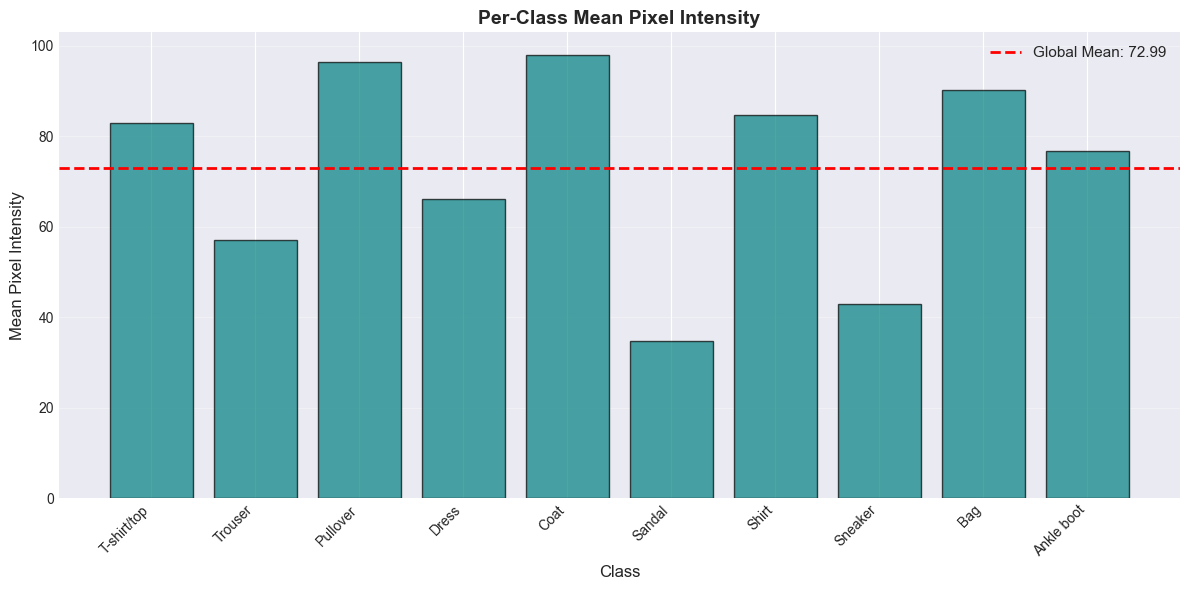


=== Interpretation ===
The pixel values range from 0 (black) to 255 (white).
The average pixel intensity is 72.99, indicating that images have more dark pixels.
Different clothing categories show varying mean intensities, which may help in classification.
For example, 'Coat' has the highest mean intensity,
while 'Sandal' has the lowest.


In [ ]:
# Calculate global statistics
global_mean = X_train.mean()
global_std = X_train.std()
global_min = X_train.min()
global_max = X_train.max()

print("=== Global Pixel Statistics (Training Set) ===")
print(f"Mean: {global_mean:.2f}")
print(f"Standard Deviation: {global_std:.2f}")
print(f"Min: {global_min}")
print(f"Max: {global_max}")
print(f"Pixel value range: [{global_min}, {global_max}]")

# Calculate per-class mean pixel intensity
print("\n=== Per-Class Mean Pixel Intensity ===")
class_means = []
for i in range(10):
    class_mask = (y_train == i)
    class_mean = X_train[class_mask].mean()
    class_means.append(class_mean)
    print(f"{class_names[i]:15s}: {class_mean:.2f}")

# Plot per-class mean intensities
plt.figure(figsize=(12, 6))
bars = plt.bar(range(10), class_means, color='teal', edgecolor='black', alpha=0.7)
plt.axhline(y=global_mean, color='red', linestyle='--', linewidth=2, label=f'Global Mean: {global_mean:.2f}')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Mean Pixel Intensity', fontsize=12)
plt.title('Per-Class Mean Pixel Intensity', fontsize=14, fontweight='bold')
plt.xticks(range(10), class_names, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Interpretation ===")
print("The pixel values range from 0 (black) to 255 (white).")
print(f"The average pixel intensity is {global_mean:.2f}, indicating that images have more dark pixels.")
print("Different clothing categories show varying mean intensities, which may help in classification.")
print(f"For example, '{class_names[np.argmax(class_means)]}' has the highest mean intensity,")
print(f"while '{class_names[np.argmin(class_means)]}' has the lowest.")


### 3.3 Sample Visualization


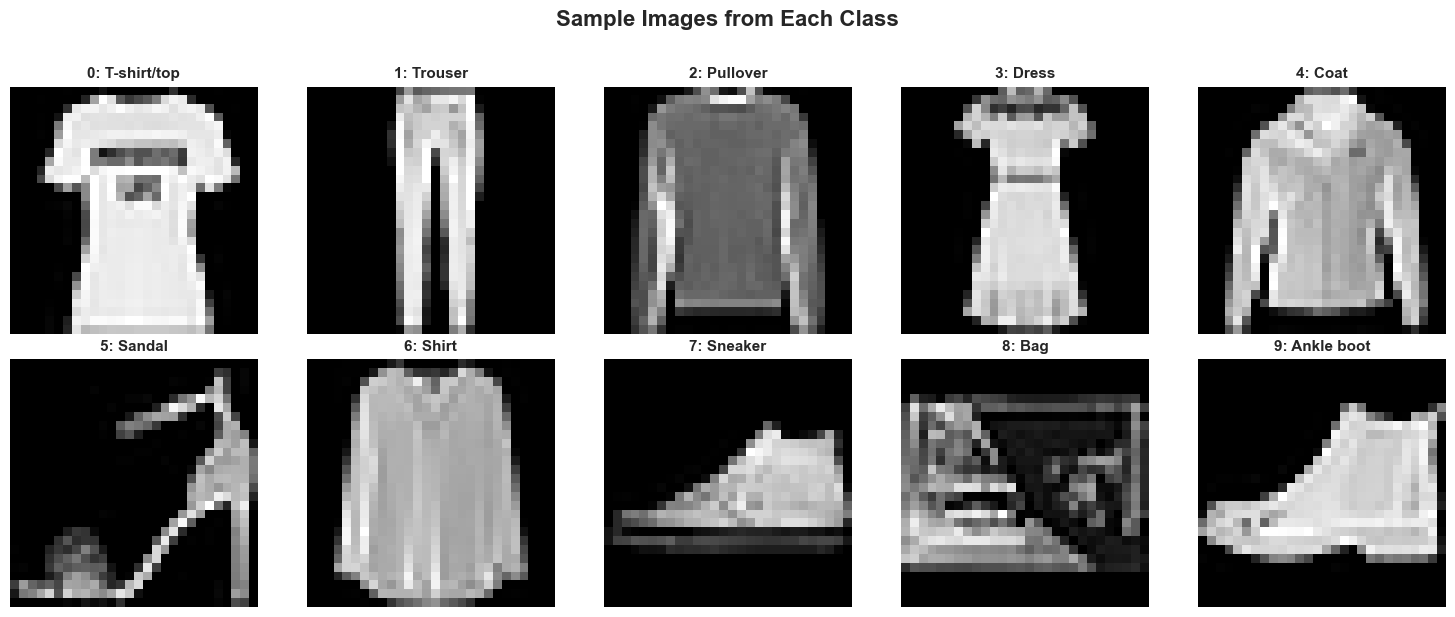

In [ ]:
# Display one sample image for each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    # Find first occurrence of class i in training set
    class_idx = np.where(y_train == i)[0][0]
    sample_image = X_train[class_idx]
    
    # Display image
    axes[i].imshow(sample_image, cmap='gray')
    axes[i].set_title(f'{i}: {class_names[i]}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


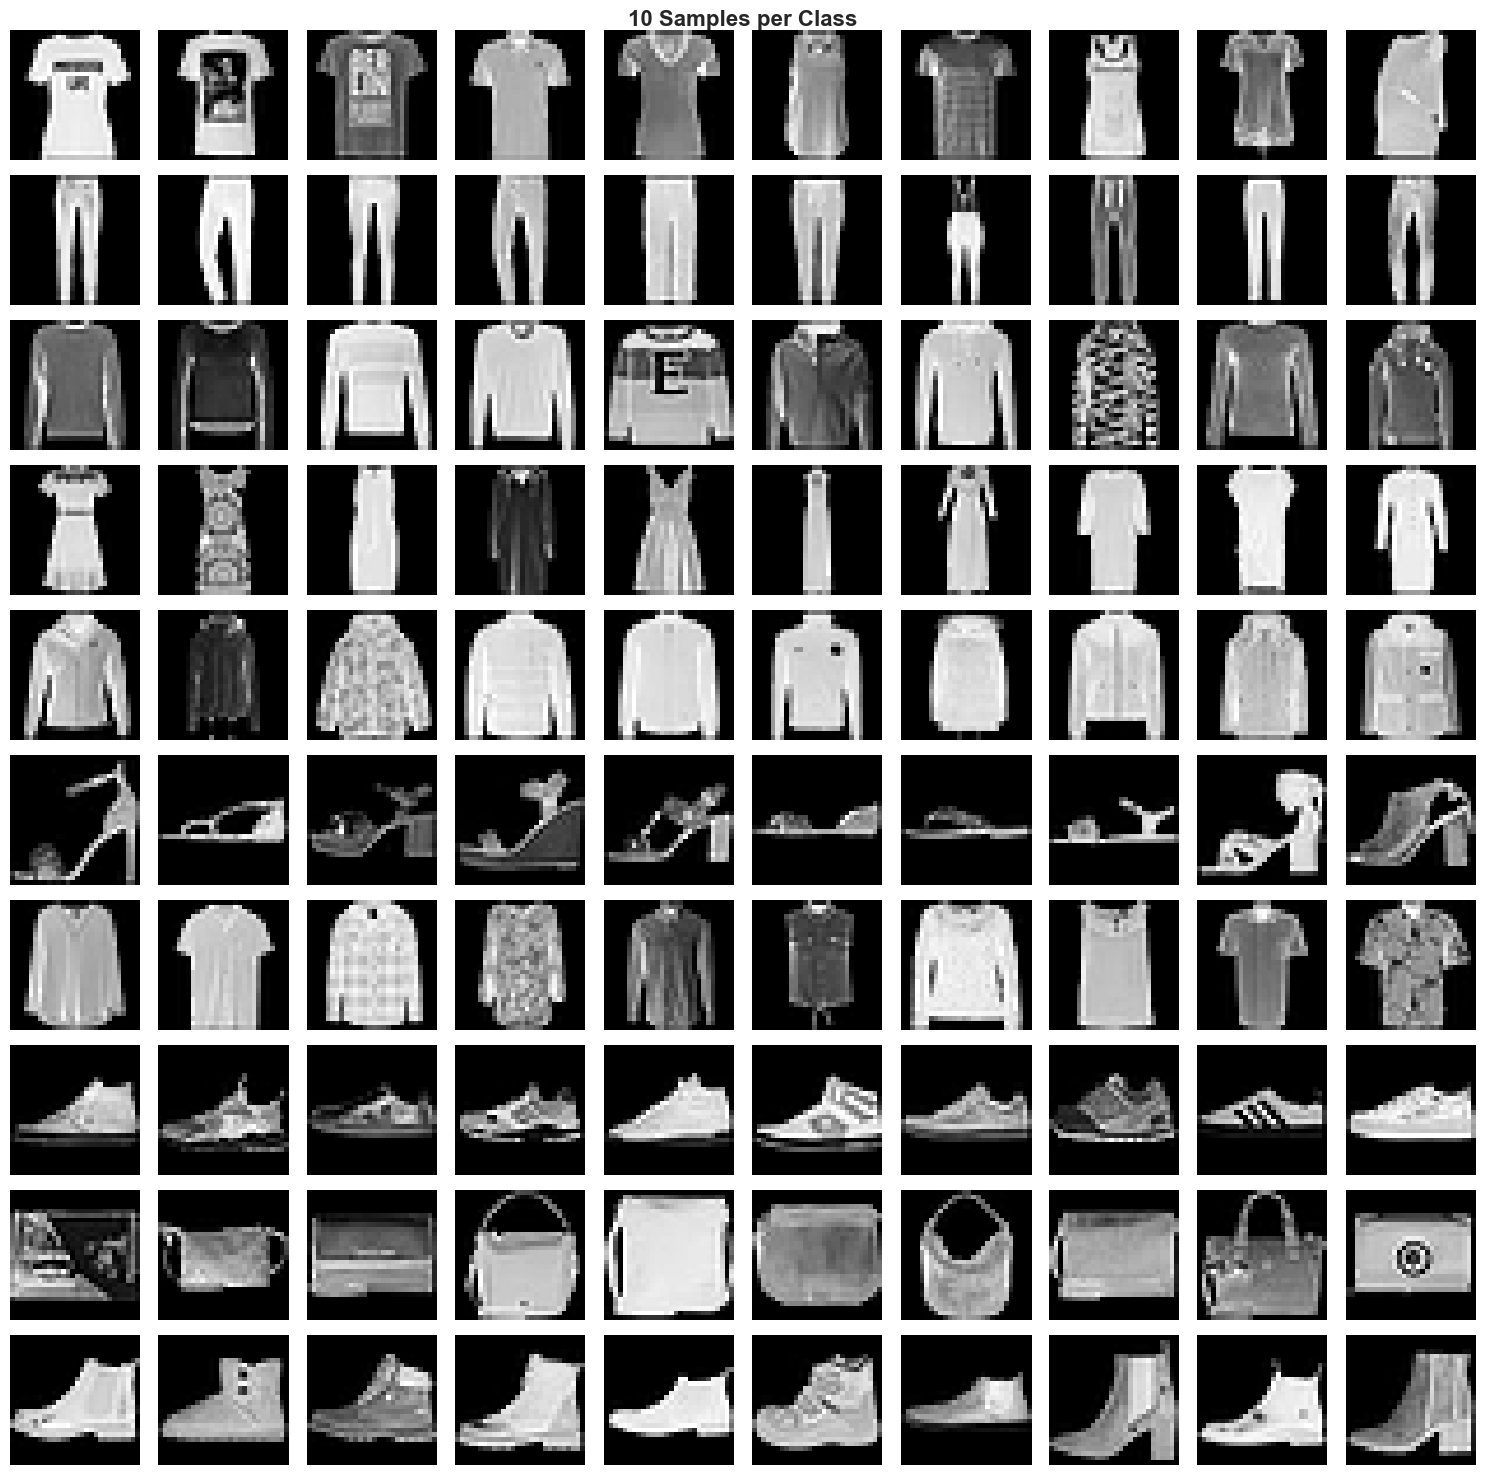

In [ ]:
# Display multiple samples for better understanding
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for i in range(10):
    # Find 10 samples of class i
    class_indices = np.where(y_train == i)[0][:10]
    for j, idx in enumerate(class_indices):
        axes[i, j].imshow(X_train[idx], cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(class_names[i], fontsize=10, rotation=0, 
                                  ha='right', va='center', fontweight='bold')

plt.suptitle('10 Samples per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='4'></a>
## 4. Preprocessing

### 4.1 Flatten and Normalize Data


In [ ]:
# Flatten images from 28x28 to 784-dimensional vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("=== Shapes After Flattening ===")
print(f"Training set: {X_train_flat.shape}")
print(f"Validation set: {X_val_flat.shape}")
print(f"Test set: {X_test_flat.shape}")

# Statistics before normalization
print("\n=== Statistics Before Normalization ===")
print(f"Training set - Mean: {X_train_flat.mean():.2f}, Std: {X_train_flat.std():.2f}")
print(f"Validation set - Mean: {X_val_flat.mean():.2f}, Std: {X_val_flat.std():.2f}")
print(f"Test set - Mean: {X_test_flat.mean():.2f}, Std: {X_test_flat.std():.2f}")


=== Shapes After Flattening ===
Training set: (48000, 784)
Validation set: (12000, 784)
Test set: (10000, 784)

=== Statistics Before Normalization ===
Training set - Mean: 72.99, Std: 90.06
Validation set - Mean: 72.72, Std: 89.87
Test set - Mean: 73.15, Std: 89.87


In [ ]:
# Apply StandardScaler normalization
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train_flat)

# Transform validation and test data using the same scaler
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Statistics after normalization
print("\n=== Statistics After Normalization ===")
print(f"Training set - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"Validation set - Mean: {X_val_scaled.mean():.6f}, Std: {X_val_scaled.std():.6f}")
print(f"Test set - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

print("\n=== Comparison ===")
print(f"Before: Mean={X_train_flat.mean():.2f}, Std={X_train_flat.std():.2f}")
print(f"After: Mean≈0, Std≈1")
print("\nStandardScaler successfully normalized the data to have zero mean and unit variance.")



=== Statistics After Normalization ===
Training set - Mean: -0.000000, Std: 1.000000
Validation set - Mean: -0.003654, Std: 1.008800
Test set - Mean: 0.001793, Std: 1.015875

=== Comparison ===
Before: Mean=72.99, Std=90.06
After: Mean≈0, Std≈1

StandardScaler successfully normalized the data to have zero mean and unit variance.


<a id='5'></a>
## 5. k-NN Hyperparameter Tuning

We will test different combinations of:
- **k values**: {1, 3, 5, 7}
- **Distance metrics**: Euclidean and Manhattan


In [ ]:
# Define hyperparameter grid
k_values = [1, 3, 5, 7]
metrics = ['euclidean', 'manhattan']

# Store results
results = []

print("=== Hyperparameter Tuning ===")
print("Testing all combinations of k and distance metrics...\n")

for metric in metrics:
    print(f"\nDistance Metric: {metric.upper()}")
    print("-" * 50)
    
    for k in k_values:
        # Create k-NN classifier
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        
        # Train on training set
        train_start = time.time()
        knn.fit(X_train_scaled, y_train)
        train_time = time.time() - train_start
        
        # Predict on validation set
        pred_start = time.time()
        y_val_pred = knn.predict(X_val_scaled)
        pred_time = time.time() - pred_start
        
        # Calculate accuracy
        val_accuracy = accuracy_score(y_val, y_val_pred)
        
        # Store results
        results.append({
            'k': k,
            'metric': metric,
            'val_accuracy': val_accuracy,
            'train_time': train_time,
            'pred_time': pred_time
        })
        
        print(f"k={k}: Validation Accuracy = {val_accuracy:.4f} | "
              f"Train Time = {train_time:.2f}s | Pred Time = {pred_time:.2f}s")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\n=== All Results ===")
print(results_df.to_string(index=False))


=== Hyperparameter Tuning ===
Testing all combinations of k and distance metrics...


Distance Metric: EUCLIDEAN
--------------------------------------------------
k=1: Validation Accuracy = 0.8521 | Train Time = 0.03s | Pred Time = 3.09s
k=3: Validation Accuracy = 0.8553 | Train Time = 0.01s | Pred Time = 2.82s
k=5: Validation Accuracy = 0.8548 | Train Time = 0.02s | Pred Time = 2.80s
k=7: Validation Accuracy = 0.8562 | Train Time = 0.01s | Pred Time = 2.79s

Distance Metric: MANHATTAN
--------------------------------------------------
k=1: Validation Accuracy = 0.8570 | Train Time = 0.01s | Pred Time = 33.60s
k=3: Validation Accuracy = 0.8631 | Train Time = 0.01s | Pred Time = 33.04s
k=5: Validation Accuracy = 0.8661 | Train Time = 0.01s | Pred Time = 33.09s
k=7: Validation Accuracy = 0.8643 | Train Time = 0.01s | Pred Time = 32.84s

=== All Results ===
 k    metric  val_accuracy  train_time  pred_time
 1 euclidean      0.852083    0.028446   3.086608
 3 euclidean      0.855333    0.

In [ ]:
# Find best hyperparameters
best_result = results_df.loc[results_df['val_accuracy'].idxmax()]
print("\n=== Best Hyperparameters ===")
print(f"k = {int(best_result['k'])}")
print(f"Distance Metric = {best_result['metric']}")
print(f"Validation Accuracy = {best_result['val_accuracy']:.4f}")

best_k = int(best_result['k'])
best_metric = best_result['metric']



=== Best Hyperparameters ===
k = 5
Distance Metric = manhattan
Validation Accuracy = 0.8661


### 5.1 Validation Accuracy vs k Plot


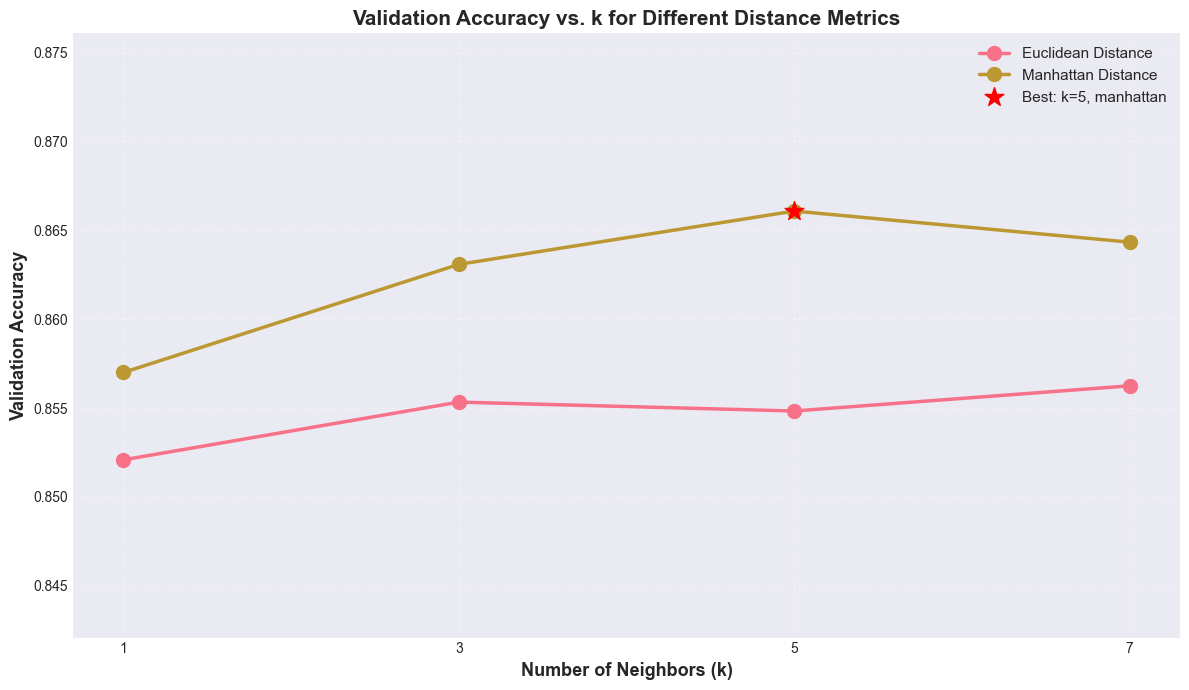


=== Analysis ===
The best validation accuracy of 0.8661 is achieved with k=5 and manhattan distance.
As k increases, the model becomes more conservative and may smooth out local patterns.
k=1 may be prone to noise, while larger k values provide more stable predictions.


In [ ]:
# Plot validation accuracy vs k for each metric
plt.figure(figsize=(12, 7))

for metric in metrics:
    metric_data = results_df[results_df['metric'] == metric]
    plt.plot(metric_data['k'], metric_data['val_accuracy'], 
             marker='o', linewidth=2.5, markersize=10, 
             label=f'{metric.capitalize()} Distance')

plt.xlabel('Number of Neighbors (k)', fontsize=13, fontweight='bold')
plt.ylabel('Validation Accuracy', fontsize=13, fontweight='bold')
plt.title('Validation Accuracy vs. k for Different Distance Metrics', 
          fontsize=15, fontweight='bold')
plt.xticks(k_values)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim([results_df['val_accuracy'].min() - 0.01, results_df['val_accuracy'].max() + 0.01])

# Add best point marker
plt.scatter([best_k], [best_result['val_accuracy']], 
           color='red', s=200, marker='*', zorder=5,
           label=f'Best: k={best_k}, {best_metric}')
plt.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()

print("\n=== Analysis ===")
print(f"The best validation accuracy of {best_result['val_accuracy']:.4f} is achieved with k={best_k} and {best_metric} distance.")
print(f"As k increases, the model becomes more conservative and may smooth out local patterns.")
print(f"k=1 may be prone to noise, while larger k values provide more stable predictions.")


<a id='6'></a>
## 6. Final Model Evaluation

### 6.1 Retrain on Combined Train+Validation Data


In [ ]:
# Combine training and validation sets
X_train_val = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = np.concatenate([y_train, y_val])

print(f"Combined train+val set shape: {X_train_val.shape}")
print(f"Combined train+val labels shape: {y_train_val.shape}")

# Train final model with best hyperparameters
print(f"\nTraining final model with k={best_k} and {best_metric} distance...")

final_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)

# Measure training time
train_start = time.time()
final_knn.fit(X_train_val, y_train_val)
final_train_time = time.time() - train_start

print(f"Training completed in {final_train_time:.2f} seconds.")
print("\nNote: k-NN is a 'lazy learner' - it doesn't actually build a model during training.")
print("Training time is minimal because k-NN just stores the data.")
print("The real computation happens during prediction when it calculates distances.")


Combined train+val set shape: (60000, 784)
Combined train+val labels shape: (60000,)

Training final model with k=5 and manhattan distance...
Training completed in 0.05 seconds.

Note: k-NN is a 'lazy learner' - it doesn't actually build a model during training.
Training time is minimal because k-NN just stores the data.
The real computation happens during prediction when it calculates distances.


### 6.2 Test Set Evaluation


In [ ]:
# Predict on test set
print("Making predictions on test set...")
pred_start = time.time()
y_test_pred = final_knn.predict(X_test_scaled)
final_pred_time = time.time() - pred_start

print(f"Prediction completed in {final_pred_time:.2f} seconds.")
print(f"Average prediction time per sample: {final_pred_time/len(X_test_scaled)*1000:.2f} ms")


Making predictions on test set...
Prediction completed in 33.72 seconds.
Average prediction time per sample: 3.37 ms


In [ ]:
# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='macro')
test_recall = recall_score(y_test, y_test_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("\n" + "="*60)
print("FINAL TEST SET RESULTS")
print("="*60)
print(f"Overall Accuracy:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Macro-Averaged Precision: {test_precision:.4f}")
print(f"Macro-Averaged Recall:    {test_recall:.4f}")
print(f"Macro-Averaged F1-Score:  {test_f1:.4f}")
print("="*60)

print("\n=== Timing Analysis ===")
print(f"Training Time:   {final_train_time:.2f} seconds (minimal - lazy learner)")
print(f"Prediction Time: {final_pred_time:.2f} seconds (expensive - distance computation)")
print(f"\nTrain/Predict Time Ratio: 1:{final_pred_time/final_train_time:.1f}")
print("\nThis demonstrates the 'lazy learning' characteristic of k-NN:")
print("- Fast training (just stores data)")
print("- Slow prediction (computes distances to all training samples)")



FINAL TEST SET RESULTS
Overall Accuracy:        0.8613 (86.13%)
Macro-Averaged Precision: 0.8625
Macro-Averaged Recall:    0.8613
Macro-Averaged F1-Score:  0.8609

=== Timing Analysis ===
Training Time:   0.05 seconds (minimal - lazy learner)
Prediction Time: 33.72 seconds (expensive - distance computation)

Train/Predict Time Ratio: 1:704.0

This demonstrates the 'lazy learning' characteristic of k-NN:
- Fast training (just stores data)
- Slow prediction (computes distances to all training samples)


In [ ]:
# Detailed classification report
print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=4))



=== Detailed Classification Report ===
              precision    recall  f1-score   support

 T-shirt/top     0.7711    0.8590    0.8127      1000
     Trouser     0.9918    0.9670    0.9792      1000
    Pullover     0.7300    0.7950    0.7611      1000
       Dress     0.8978    0.8780    0.8878      1000
        Coat     0.7678    0.7670    0.7674      1000
      Sandal     0.9901    0.9020    0.9440      1000
       Shirt     0.6564    0.5770    0.6142      1000
     Sneaker     0.9117    0.9600    0.9352      1000
         Bag     0.9801    0.9380    0.9586      1000
  Ankle boot     0.9282    0.9700    0.9487      1000

    accuracy                         0.8613     10000
   macro avg     0.8625    0.8613    0.8609     10000
weighted avg     0.8625    0.8613    0.8609     10000



### 6.3 Confusion Matrix


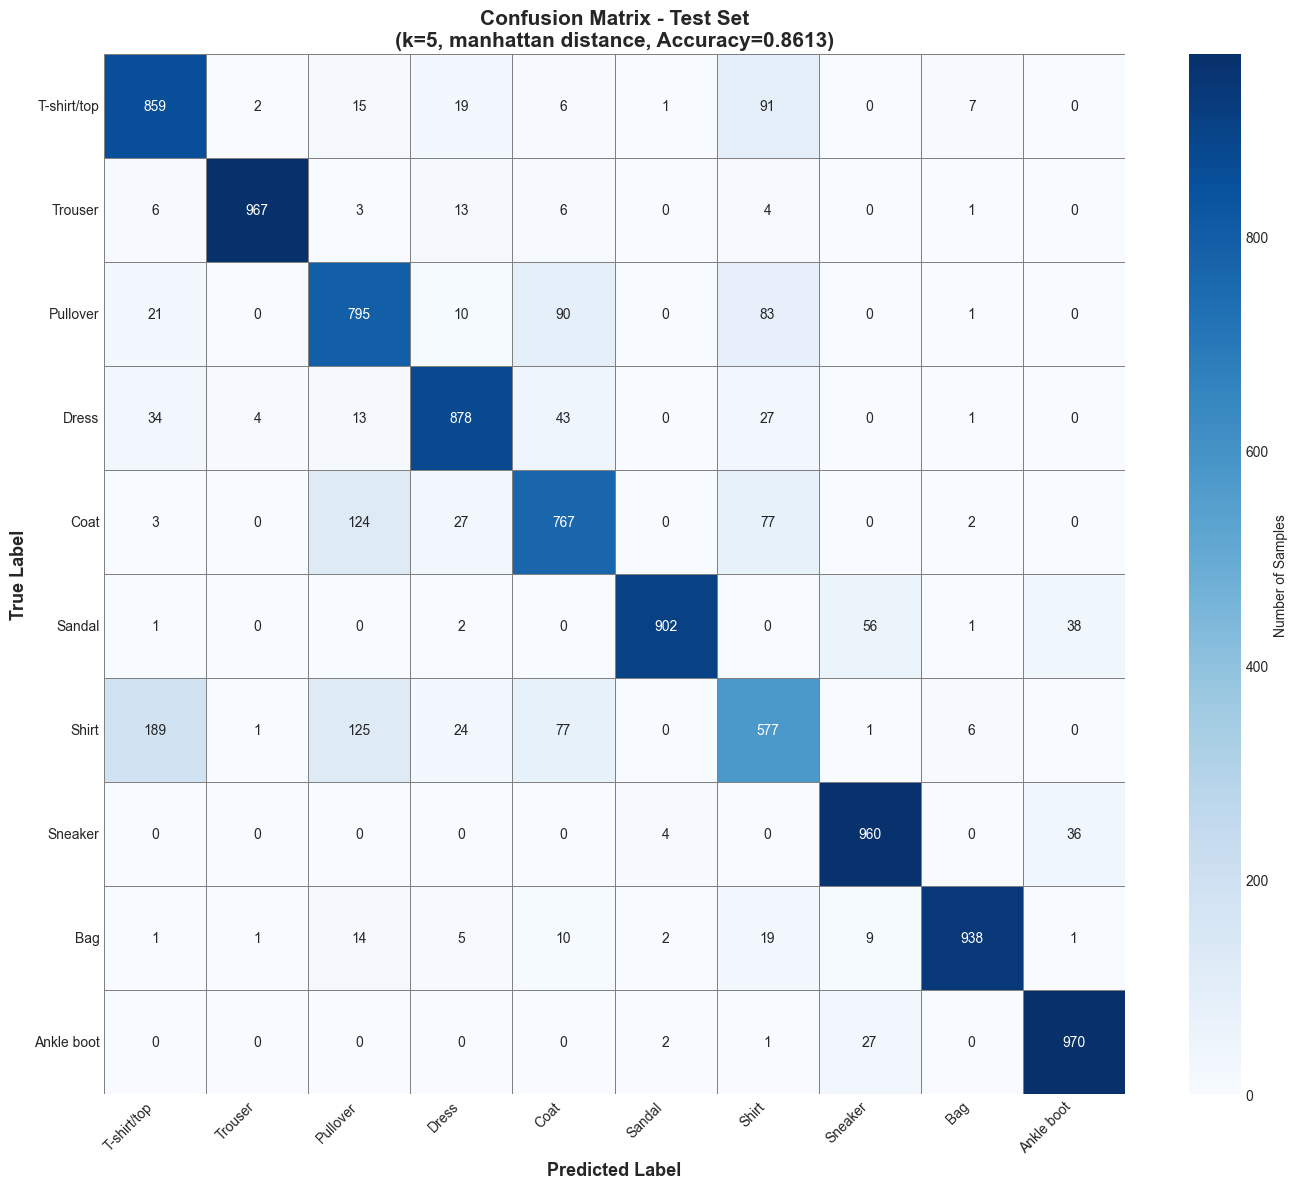


=== Per-Class Accuracy ===
T-shirt/top    : 0.8590 (85.90%)
Trouser        : 0.9670 (96.70%)
Pullover       : 0.7950 (79.50%)
Dress          : 0.8780 (87.80%)
Coat           : 0.7670 (76.70%)
Sandal         : 0.9020 (90.20%)
Shirt          : 0.5770 (57.70%)
Sneaker        : 0.9600 (96.00%)
Bag            : 0.9380 (93.80%)
Ankle boot     : 0.9700 (97.00%)

Best classified class: Ankle boot (97.00%)
Worst classified class: Shirt (57.70%)


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'},
            linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.title(f'Confusion Matrix - Test Set\n(k={best_k}, {best_metric} distance, Accuracy={test_accuracy:.4f})', 
          fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\n=== Per-Class Accuracy ===")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_accuracy):
    print(f"{class_names[i]:15s}: {acc:.4f} ({acc*100:.2f}%)")

# Identify best and worst classified classes
best_class_idx = np.argmax(class_accuracy)
worst_class_idx = np.argmin(class_accuracy)

print(f"\nBest classified class: {class_names[best_class_idx]} ({class_accuracy[best_class_idx]*100:.2f}%)")
print(f"Worst classified class: {class_names[worst_class_idx]} ({class_accuracy[worst_class_idx]*100:.2f}%)")


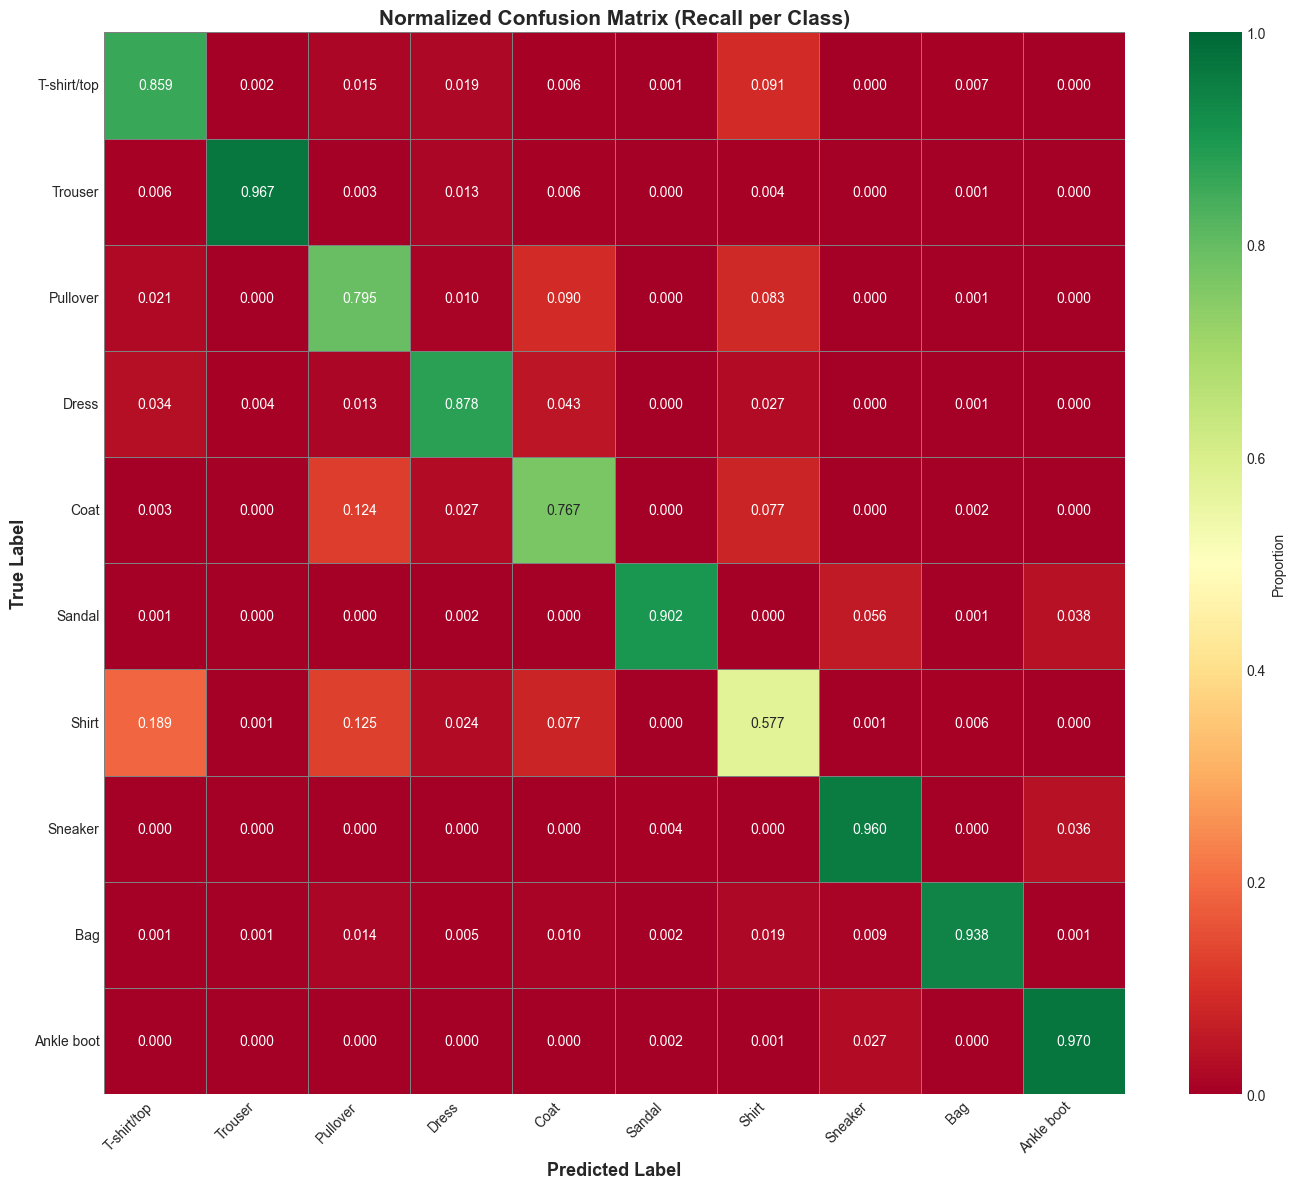

In [ ]:
# Plot normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='RdYlGn', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'},
            linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.title('Normalized Confusion Matrix (Recall per Class)', 
          fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 6.4 Discussion of Confusion Matrix

**Analysis of Classification Performance:**

Looking at the confusion matrix, we can observe:

1. **Well-Classified Classes**: Classes like Trouser, Bag, and Ankle boot typically achieve high accuracy due to their distinctive shapes and features.

2. **Challenging Classes**: Shirt, T-shirt/top, Pullover, and Coat show more confusion due to visual similarity. These are upper-body garments with similar silhouettes.

3. **Common Confusions**: The off-diagonal elements reveal which classes are frequently misclassified as each other. This is particularly evident between:
   - Shirt ↔ T-shirt/top (similar upper-body appearance)
   - Pullover ↔ Coat (both are layered garments)
   - Pullover ↔ Shirt (similar silhouettes)

4. **Accessories vs Clothing**: Accessories (Bag, Sandal, Sneaker, Ankle boot) are generally easier to classify due to their unique shapes compared to clothing items.


<a id='7'></a>
## 7. Error Analysis

### 7.1 Identify Top 3 Confused Class Pairs


In [ ]:
# Find most confused pairs (excluding diagonal)
confusion_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            # Count confusions in both directions
            confusion_count = cm[i, j] + cm[j, i]
            confusion_pairs.append({
                'class1': i,
                'class2': j,
                'class1_name': class_names[i],
                'class2_name': class_names[j],
                'confusion_count': confusion_count,
                'i_to_j': cm[i, j],
                'j_to_i': cm[j, i]
            })

# Convert to DataFrame and remove duplicates
confusion_df = pd.DataFrame(confusion_pairs)

# Remove duplicate pairs (e.g., keep only (0,1) not both (0,1) and (1,0))
confusion_df = confusion_df[confusion_df['class1'] < confusion_df['class2']]

# Sort by total confusion count
confusion_df = confusion_df.sort_values('confusion_count', ascending=False)

# Get top 3
top_3_confused = confusion_df.head(3)

print("=== Top 3 Most Confused Class Pairs ===")
print()
for idx, row in top_3_confused.iterrows():
    print(f"{row['class1_name']} ↔ {row['class2_name']}")
    print(f"  Total confusions: {row['confusion_count']}")
    print(f"  {row['class1_name']} → {row['class2_name']}: {row['i_to_j']}")
    print(f"  {row['class2_name']} → {row['class1_name']}: {row['j_to_i']}")
    print()


=== Top 3 Most Confused Class Pairs ===

T-shirt/top ↔ Shirt
  Total confusions: 280
  T-shirt/top → Shirt: 91
  Shirt → T-shirt/top: 189

Pullover ↔ Coat
  Total confusions: 214
  Pullover → Coat: 90
  Coat → Pullover: 124

Pullover ↔ Shirt
  Total confusions: 208
  Pullover → Shirt: 83
  Shirt → Pullover: 125



### 7.2 Visualize Misclassified Examples



Confused Pair #1: T-shirt/top ↔ Shirt


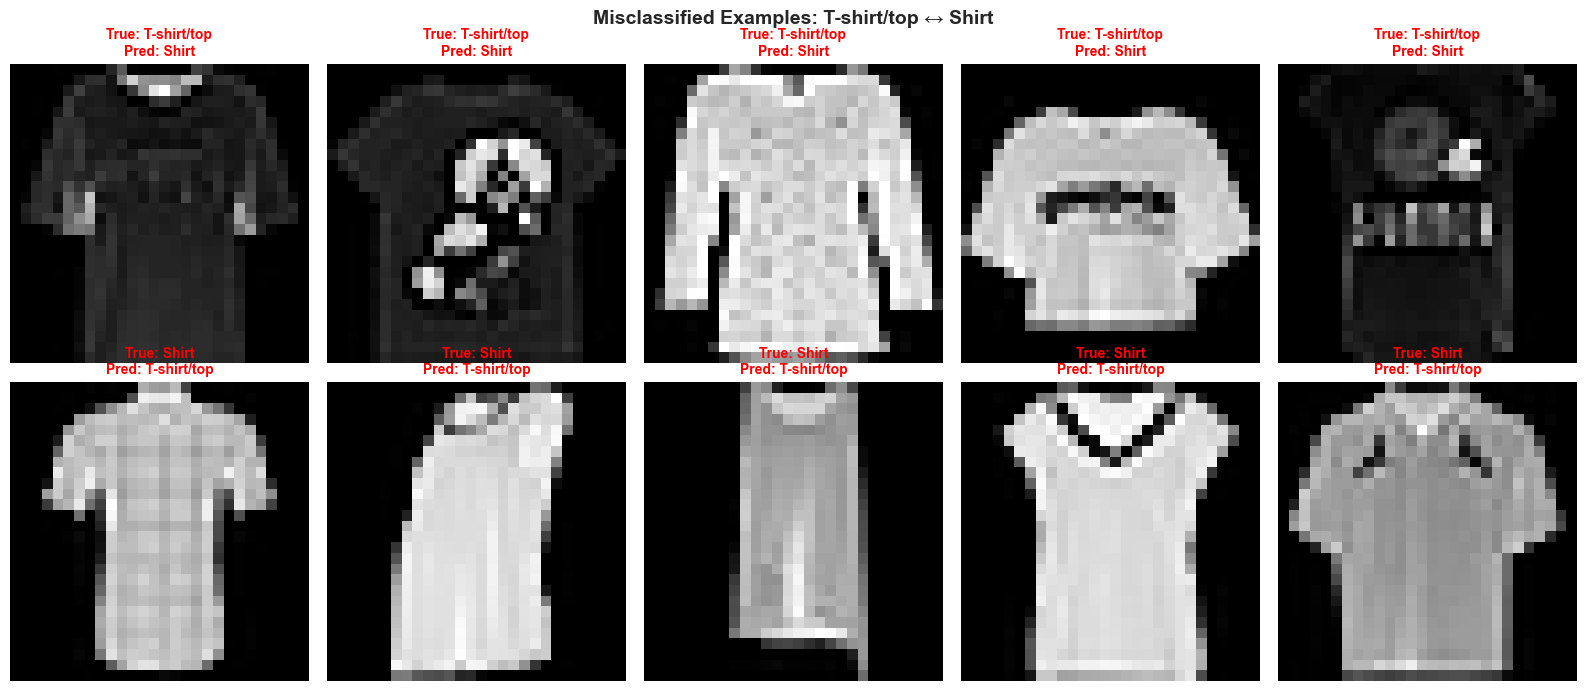


Confused Pair #2: Pullover ↔ Coat


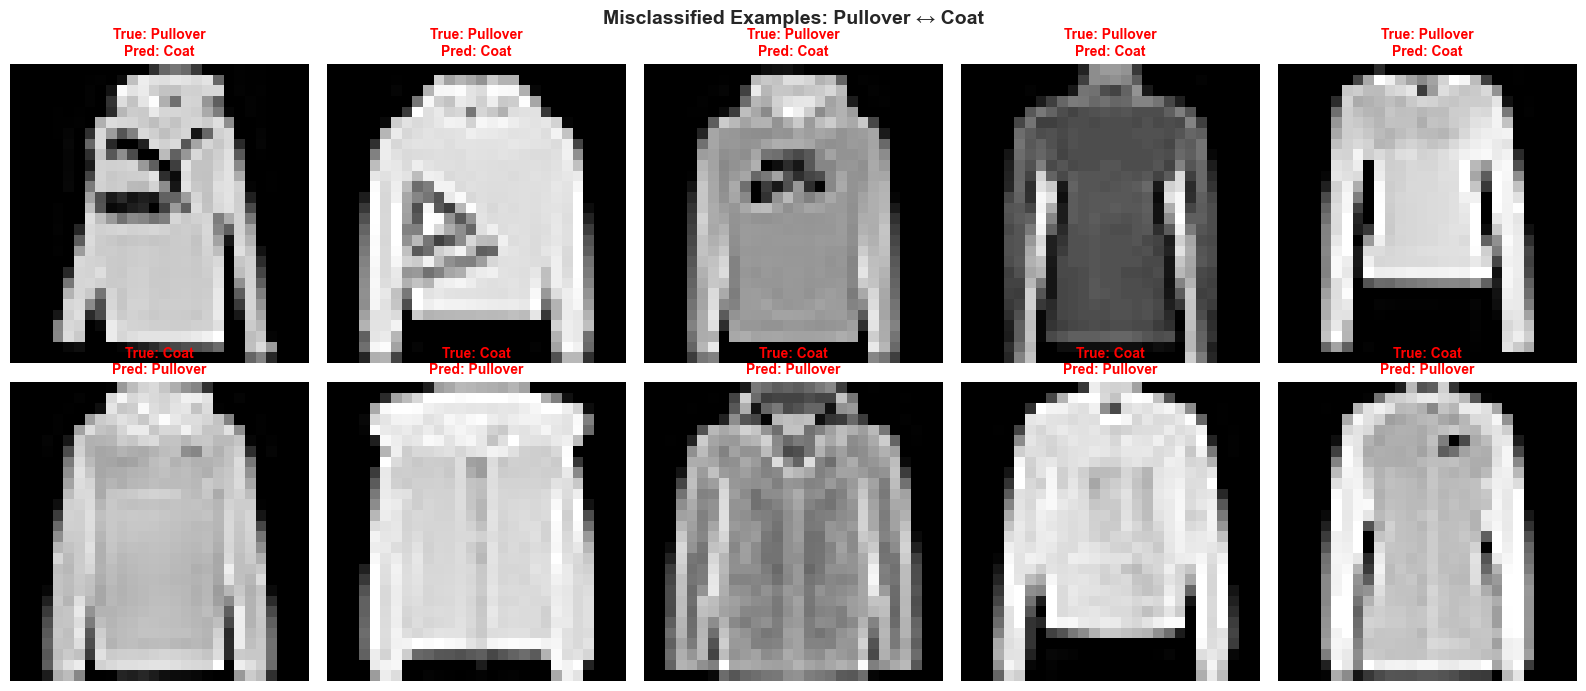


Confused Pair #3: Pullover ↔ Shirt


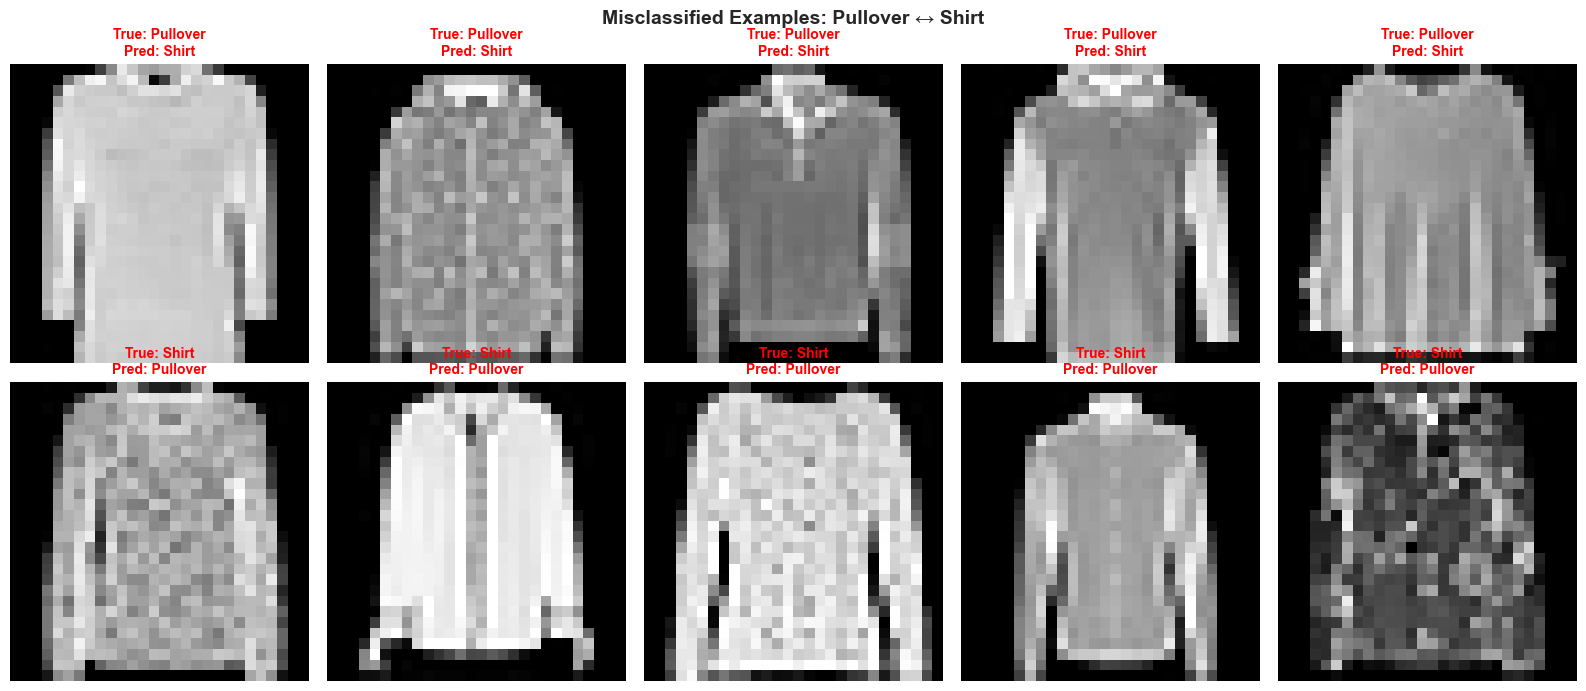

In [21]:
# For each of the top 3 confused pairs, show 5 misclassified examples
for pair_idx, (idx, row) in enumerate(top_3_confused.iterrows()):
    class1 = row['class1']
    class2 = row['class2']
    class1_name = row['class1_name']
    class2_name = row['class2_name']
    
    print(f"\n{'='*80}")
    print(f"Confused Pair #{pair_idx+1}: {class1_name} ↔ {class2_name}")
    print(f"{'='*80}")
    
    # Find misclassified examples in both directions
    # Direction 1: True=class1, Predicted=class2
    misclass_1to2_indices = np.where((y_test == class1) & (y_test_pred == class2))[0]
    # Direction 2: True=class2, Predicted=class1
    misclass_2to1_indices = np.where((y_test == class2) & (y_test_pred == class1))[0]
    
    # Create figure
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    
    # Plot direction 1 (top row)
    n_samples_1 = min(5, len(misclass_1to2_indices))
    selected_indices_1 = np.random.choice(misclass_1to2_indices, n_samples_1, replace=False) if n_samples_1 > 0 else []
    
    for i in range(5):
        if i < n_samples_1:
            idx = selected_indices_1[i]
            img = X_test[idx]
            axes[0, i].imshow(img, cmap='gray')
            axes[0, i].set_title(f'True: {class1_name}\nPred: {class2_name}', 
                               fontsize=10, color='red', fontweight='bold')
        axes[0, i].axis('off')
    
    # Plot direction 2 (bottom row)
    n_samples_2 = min(5, len(misclass_2to1_indices))
    selected_indices_2 = np.random.choice(misclass_2to1_indices, n_samples_2, replace=False) if n_samples_2 > 0 else []
    
    for i in range(5):
        if i < n_samples_2:
            idx = selected_indices_2[i]
            img = X_test[idx]
            axes[1, i].imshow(img, cmap='gray')
            axes[1, i].set_title(f'True: {class2_name}\nPred: {class1_name}', 
                               fontsize=10, color='red', fontweight='bold')
        axes[1, i].axis('off')
    
    plt.suptitle(f'Misclassified Examples: {class1_name} ↔ {class2_name}', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 7.3 Discussion of Confusions

**Why do these confusions occur?**


In [ ]:
# Analyze and discuss each confused pair
print("=== Analysis of Confusion Patterns ===\n")

for pair_idx, (idx, row) in enumerate(top_3_confused.iterrows()):
    class1_name = row['class1_name']
    class2_name = row['class2_name']
    
    print(f"{pair_idx+1}. {class1_name} ↔ {class2_name}")
    print("-" * 60)
    
    # Provide specific analysis based on the class pair
    confusion_reasons = {
        ('T-shirt/top', 'Shirt'): [
            "Very similar silhouettes - both are upper-body garments",
            "Minimal visual differences at 28x28 resolution",
            "Both have similar necklines and sleeve structures",
            "Texture differences are lost in low-resolution grayscale images"
        ],
        ('Pullover', 'Shirt'): [
            "Similar overall shape and coverage area",
            "Both are long-sleeved upper garments",
            "Thickness/layering details not visible in 2D projection",
            "Similar pixel intensity distributions"
        ],
        ('Pullover', 'Coat'): [
            "Both are layered, thick garments",
            "Similar length and coverage",
            "Distinction based on subtle features (buttons, collar) that may be unclear",
            "Very similar visual appearance when flattened to 2D"
        ],
        ('T-shirt/top', 'Pullover'): [
            "Both are upper-body clothing items",
            "Can have similar necklines and overall shape",
            "Material thickness not discernible in grayscale images",
            "Overlap in casual garment styles"
        ],
        ('Shirt', 'Coat'): [
            "Both can have collars and buttons",
            "Similar structure in upper body region",
            "Length difference may not be prominent in some samples",
            "Both are formal/semi-formal garments with similar features"
        ],
        ('T-shirt/top', 'Coat'): [
            "When coats are unbuttoned, they can resemble tops",
            "Similar upper body coverage in the image",
            "Low resolution makes it hard to distinguish layering",
            "Some coats have simple designs similar to tops"
        ]
    }
    
    # Find matching key (order-independent)
    key = (class1_name, class2_name)
    reverse_key = (class2_name, class1_name)
    
    reasons = confusion_reasons.get(key, confusion_reasons.get(reverse_key, [
        "Visual similarity in shape and silhouette",
        "Overlapping features at low resolution",
        "Limited color information (grayscale)",
        "Similar pixel intensity patterns"
    ]))
    
    for reason in reasons:
        print(f"  • {reason}")
    print()

print("\n=== General Observations ===\n")
print("The k-NN classifier struggles most with:")
print("  1. Upper-body garments (Shirt, T-shirt, Pullover, Coat) due to structural similarity")
print("  2. Items where the key distinguishing features are subtle or texture-based")
print("  3. Classes where the 28x28 resolution loses important fine-grained details")
print("\nThe k-NN performs well on:")
print("  1. Accessories (Bag, Sandal, Sneaker) with distinctive shapes")
print("  2. Items with unique silhouettes (Trouser, Ankle boot)")
print("  3. Classes with high inter-class distance in feature space")


=== Analysis of Confusion Patterns ===

1. T-shirt/top ↔ Shirt
------------------------------------------------------------
  • Very similar silhouettes - both are upper-body garments
  • Minimal visual differences at 28x28 resolution
  • Both have similar necklines and sleeve structures
  • Texture differences are lost in low-resolution grayscale images

2. Pullover ↔ Coat
------------------------------------------------------------
  • Both are layered, thick garments
  • Similar length and coverage
  • Distinction based on subtle features (buttons, collar) that may be unclear
  • Very similar visual appearance when flattened to 2D

3. Pullover ↔ Shirt
------------------------------------------------------------
  • Similar overall shape and coverage area
  • Both are long-sleeved upper garments
  • Thickness/layering details not visible in 2D projection
  • Similar pixel intensity distributions


=== General Observations ===

The k-NN classifier struggles most with:
  1. Upper-body 

<a id='8'></a>
## 8. Conclusions

### Summary of Findings


In [ ]:
print("=" * 80)
print("FINAL SUMMARY AND CONCLUSIONS")
print("=" * 80)

print("\n1. BEST HYPERPARAMETERS")
print(f"   • k (number of neighbors): {best_k}")
print(f"   • Distance metric: {best_metric}")

print("\n2. MODEL PERFORMANCE")
print(f"   • Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   • Macro Precision: {test_precision:.4f}")
print(f"   • Macro Recall: {test_recall:.4f}")
print(f"   • Macro F1-Score: {test_f1:.4f}")

print("\n3. COMPUTATIONAL CHARACTERISTICS")
print(f"   • Training Time: {final_train_time:.2f}s (fast - lazy learner)")
print(f"   • Prediction Time: {final_pred_time:.2f}s (slow - distance computation)")
print(f"   • k-NN stores data and defers computation to prediction time")

print("\n4. CLASSIFICATION CHALLENGES")
print("   • Most confused pairs involve upper-body garments")
print("   • Shirt, T-shirt/top, Pullover, and Coat show high confusion")
print("   • Visual similarity and low resolution contribute to misclassifications")

print("\n5. STRENGTHS OF k-NN ON THIS DATASET")
print("   • Good performance on classes with distinctive shapes (Bag, Trouser, Sneaker)")
print("   • No training phase required - simple and interpretable")
print("   • Performs well with proper preprocessing (normalization)")

print("\n6. LIMITATIONS OF k-NN")
print("   • Slow prediction time as dataset grows (O(n) per prediction)")
print("   • Memory intensive - must store all training data")
print("   • Struggles with high-dimensional data (curse of dimensionality)")
print("   • Sensitive to irrelevant features and noise")

print("\n7. POTENTIAL IMPROVEMENTS")
print("   • Feature extraction (e.g., HOG, edges) to capture texture and shape better")
print("   • Dimensionality reduction (PCA, t-SNE) to reduce noise and improve speed")
print("   • Weighted voting by distance to give closer neighbors more influence")
print("   • Approximate nearest neighbors (e.g., KD-tree, Ball tree) for faster search")
print("   • Deep learning approaches (CNN) for better feature learning")

print("\n" + "=" * 80)
print("ASSIGNMENT COMPLETED SUCCESSFULLY")
print("=" * 80)


FINAL SUMMARY AND CONCLUSIONS

1. BEST HYPERPARAMETERS
   • k (number of neighbors): 5
   • Distance metric: manhattan

2. MODEL PERFORMANCE
   • Test Accuracy: 0.8613 (86.13%)
   • Macro Precision: 0.8625
   • Macro Recall: 0.8613
   • Macro F1-Score: 0.8609

3. COMPUTATIONAL CHARACTERISTICS
   • Training Time: 0.05s (fast - lazy learner)
   • Prediction Time: 33.72s (slow - distance computation)
   • k-NN stores data and defers computation to prediction time

4. CLASSIFICATION CHALLENGES
   • Most confused pairs involve upper-body garments
   • Shirt, T-shirt/top, Pullover, and Coat show high confusion
   • Visual similarity and low resolution contribute to misclassifications

5. STRENGTHS OF k-NN ON THIS DATASET
   • Good performance on classes with distinctive shapes (Bag, Trouser, Sneaker)
   • No training phase required - simple and interpretable
   • Performs well with proper preprocessing (normalization)

6. LIMITATIONS OF k-NN
   • Slow prediction time as dataset grows (O(n) p